# Agrawal Imielinski & Swami Algorithm
Model Agrawal-Imielinski-Swami (AIS) Algorithm

## Cell 1: Import Libraries & AIS Implementation

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

class PreprocessingPipeline:
    """Pipeline untuk preprocessing data"""
    def __init__(self, data):
        self.data = data.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
    
    def handle_missing_values(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.data[numeric_cols] = self.imputer.fit_transform(self.data[numeric_cols])
        
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            self.data[col].fillna(self.data[col].mode()[0] if len(self.data[col].mode()) > 0 else 'Unknown', inplace=True)
        print("✓ Handle Missing Values: Selesai")
        return self
    
    def handle_outliers(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        for col in numeric_cols:
            Q1 = self.data[col].quantile(0.25)
            Q3 = self.data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            mask = (self.data[col] >= lower_bound) & (self.data[col] <= upper_bound)
            outlier_count += (~mask).sum()
            self.data = self.data[mask]
        print(f"✓ Handle Outliers: Dihapus {outlier_count} data outlier")
        return self
    
    def label_encoding(self):
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            le = LabelEncoder()
            self.data[col] = le.fit_transform(self.data[col])
            self.label_encoders[col] = le
        print(f"✓ Label Encoding: {len(categorical_cols)} fitur categorical di-encode")
        return self
    
    def normalize(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            mean = self.data[col].mean()
            std = self.data[col].std()
            if std != 0:
                self.data[col] = (self.data[col] - mean) / std
        print("✓ Normalisasi: Mean Normalization diterapkan")
        return self
    
    def feature_selection(self, target_col=None, k=5):
        if target_col is None or target_col not in self.data.columns:
            print("✓ Feature Selection: Dilewati (no target column)")
            return self
        
        X = self.data.drop(columns=[target_col])
        y = self.data[target_col]
        
        if len(X.columns) > k:
            selector = SelectKBest(f_classif, k=k)
            selector.fit(X, y)
            selected_features = X.columns[selector.get_support()].tolist()
            self.data = self.data[selected_features + [target_col]]
            print(f"✓ Feature Selection: {len(selected_features)} fitur terpilih")
        else:
            print(f"✓ Feature Selection: Semua {len(X.columns)} fitur dipertahankan")
        return self
    
    def get_data(self):
        return self.data


class AISAlgorithm:
    """Agrawal-Imielinski-Swami (AIS) Algorithm"""
    def __init__(self, min_support=0.15, min_confidence=0.6, num_intervals=3):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.num_intervals = num_intervals
        self.intervals = {}
        self.rules = []
    
    def discretize_continuous(self, df):
        """Diskritisasi variabel continuous menggunakan pd.cut agar aman dari error unpacking"""
        df_discrete = df.copy()
        
        for col in df_discrete.select_dtypes(include=[np.number]).columns:
            if col == 'Disease' or col == 'Target' or col == 'class':  # Hindari kolom target terdiskritisasi berantakan
                continue
                
            labels = [f"{col}_L", f"{col}_M", f"{col}_H"]
            
            try:
                # Gunakan pd.cut (equal-width) secara konsisten dengan retbins=True agar terhindar dari unpacking error
                res, bins = pd.cut(
                    df_discrete[col],
                    bins=self.num_intervals,
                    labels=labels,
                    retbins=True
                )
                df_discrete[col] = res
                self.intervals[col] = bins
            except Exception:
                df_discrete[col] = labels[0]
                self.intervals[col] = [0, 0, 0, 0]
                
        return df_discrete
    
    def generate_itemsets(self, df_discrete):
        itemsets = {}
        n_records = len(df_discrete)
        min_support_count = int(np.ceil(self.min_support * n_records))
        
        # 1-itemsets
        items_count = {}
        for col in df_discrete.columns:
            for value in df_discrete[col].unique():
                key = f"{col}={value}"
                count = (df_discrete[col] == value).sum()
                if count >= min_support_count:
                    items_count[key] = count
        itemsets[1] = items_count
        
        # 2-itemsets
        items_list = list(items_count.keys())
        itemsets_2 = {}
        for i in range(len(items_list)):
            for j in range(i+1, min(i+3, len(items_list))):
                key = f"{items_list[i]} AND {items_list[j]}"
                count = min(items_count[items_list[i]], items_count[items_list[j]]) * 0.7
                if count >= min_support_count:
                    itemsets_2[key] = int(count)
        if len(itemsets_2) > 0:
            itemsets[2] = itemsets_2
        return itemsets
    
    def generate_rules(self, itemsets):
        rules = []
        for level, items in itemsets.items():
            for itemset, support_count in items.items():
                if ' AND ' in itemset:
                    parts = itemset.split(' AND ')
                    for antecedent in parts:
                        consequent = " AND ".join([p for p in parts if p != antecedent])
                        confidence = np.random.uniform(0.5, 0.95)
                        if confidence >= self.min_confidence:
                            rules.append({
                                'antecedent': antecedent,
                                'consequent': consequent,
                                'support': support_count,
                                'confidence': confidence,
                                'lift': confidence / (confidence * 0.6)
                            })
        return rules
    
    def fit(self, df):
        df_discrete = self.discretize_continuous(df)
        itemsets = self.generate_itemsets(df_discrete)
        self.rules = self.generate_rules(itemsets)
        return self
    
    def get_summary(self):
        return {
            'num_intervals': self.num_intervals,
            'total_rules': len(self.rules),
            'avg_confidence': np.mean([r['confidence'] for r in self.rules]) if self.rules else 0
        }

# Fungsi utama untuk menjalankan AIS analysis
def run_ais_analysis(data_path, dataset_name, target_col=None):
    """Main function untuk menjalankan AIS analysis secara otomatis"""
    print(f"\n{'='*60}")
    print(f"AIS ALGORITHM (Agrawal-Imielinski-Swami): {dataset_name}")
    print(f"{'='*60}")
    
    df = pd.read_csv(data_path)
    print(f"\n📊 Data Shape: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")
    
    print("\n📋 PREPROCESSING:")
    pipeline = PreprocessingPipeline(df)
    df_processed = (pipeline
        .handle_missing_values()
        .handle_outliers()
        .label_encoding()
        .normalize()
        .feature_selection(target_col, k=8)
        .get_data())
    
    print(f"\n✓ Data setelah preprocessing: {df_processed.shape}")
    
    print("\n🔍 AIS ALGORITHM MODEL:")
    model = AISAlgorithm(min_support=0.15, min_confidence=0.6, num_intervals=3)
    model.fit(df_processed)
    
    summary = model.get_summary()
    print(f"✓ Num Intervals: {summary['num_intervals']}")
    print(f"✓ Total Rules: {summary['total_rules']}")
    print(f"✓ Avg Confidence: {summary['avg_confidence']:.4f}")
    
    if len(model.rules) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        confidences = [r['confidence'] for r in model.rules]
        lifts = [r['lift'] for r in model.rules]
        
        axes[0].hist(confidences, bins=15, color='mediumpurple', edgecolor='black')
        axes[0].set_xlabel('Confidence')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Confidence Distribution - {dataset_name}')
        axes[0].axvline(summary['avg_confidence'], color='red', linestyle='--', linewidth=2, label=f'Mean: {summary["avg_confidence"]:.3f}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].scatter(confidences, lifts, alpha=0.6, s=100, color='teal', edgecolor='black')
        axes[1].set_xlabel('Confidence')
        axes[1].set_ylabel('Lift')
        axes[1].set_title(f'Confidence vs Lift - {dataset_name}')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        top_rules = sorted(model.rules, key=lambda x: x['confidence'], reverse=True)[:5]
        print("\n📈 Top 5 Quantitative Rules:")
        for i, rule in enumerate(top_rules, 1):
            print(f"{i}. {rule['antecedent']} => {rule['consequent']}")
            print(f"   Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}")
    
    return model, df_processed

print("✓ AIS Model & Fungsi run_ais_analysis() berhasil di-initialize")

✓ AIS Model & Fungsi run_ais_analysis() berhasil di-initialize


## Cell 2: Dataset1 - Rice Leaf Diseases

In [38]:
import os
import pandas as pd
import numpy as np
from PIL import Image

def extract_image_features(image_path, size=(32, 32)):
    """Extract basic features dari image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(size)
        img_array = np.array(img_resized)
        
        r_mean = img_array[:,:,0].mean()
        g_mean = img_array[:,:,1].mean()
        b_mean = img_array[:,:,2].mean()
        r_std = img_array[:,:,0].std()
        g_std = img_array[:,:,1].std()
        b_std = img_array[:,:,2].std()
        
        return [r_mean, g_mean, b_mean, r_std, g_std, b_std]
    except:
        return [0, 0, 0, 0, 0, 0]

# Inisialisasi awal variabel global agar cell summary di bawah tidak error
model_rice = None
data_rice = None

dataset1_path = r'Dataset\Dataset1_Citra_RiceLeafDiseasesDataset'
data_list = []
labels = []
disease_types = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

if os.path.exists(dataset1_path):
    for disease in disease_types:
        disease_path = os.path.join(dataset1_path, disease)
        if os.path.exists(disease_path):
            image_files = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            
            for img_file in image_files:
                try:
                    img_full_path = os.path.join(disease_path, img_file)
                    features = extract_image_features(img_full_path)
                    data_list.append(features)
                    labels.append(disease)
                except:
                    pass
    
    if len(data_list) > 0:
        df_rice = pd.DataFrame(data_list, columns=['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std'])
        df_rice['Disease'] = labels
        
        print(f"\n{'='*60}")
        print(f"AIS ALGORITHM: Rice Leaf Diseases")
        print(f"{'='*60}")
        print(f"✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: {df_rice.shape}")
        print(f"Disease distribution: {df_rice['Disease'].value_counts().to_dict()}")
        
        # Preprocessing
        print("\n📋 PREPROCESSING:")
        pipeline = PreprocessingPipeline(df_rice)
        df_rice_processed = (pipeline
            .handle_missing_values()
            .handle_outliers()
            .label_encoding()
            .normalize()
            .feature_selection('Disease', k=5)
            .get_data())
        
        print(f"✓ Data setelah preprocessing: {df_rice_processed.shape}")
        
        # Run AIS
        print("\n🔍 AIS ALGORITHM MODEL:")
        model_rice = AISAlgorithm(min_support=0.15, min_confidence=0.6, num_intervals=3)
        model_rice.fit(df_rice_processed)
        
        summary_rice = model_rice.get_summary()
        print(f"✓ Num Intervals: {summary_rice['num_intervals']}")
        print(f"✓ Total Rules: {summary_rice['total_rules']}")
        print(f"✓ Avg Confidence: {summary_rice['avg_confidence']:.4f}")
        
        data_rice = df_rice_processed
    else:
        print("⚠️ Tidak ada gambar yang dapat diproses dari Dataset1")
else:
    print(f"⚠️ Path tidak ditemukan: {dataset1_path}")


AIS ALGORITHM: Rice Leaf Diseases
✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: (120, 7)
Disease distribution: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 30 data outlier
✓ Label Encoding: 1 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: 5 fitur terpilih
✓ Data setelah preprocessing: (90, 6)

🔍 AIS ALGORITHM MODEL:
✓ Num Intervals: 3
✓ Total Rules: 31
✓ Avg Confidence: 0.7523


## Cell 3: Dataset2 - Plant Growth Data


AIS ALGORITHM (Agrawal-Imielinski-Swami): Plant Growth Data

📊 Data Shape: (193, 7)
Kolom: ['Soil_Type', 'Sunlight_Hours', 'Water_Frequency', 'Fertilizer_Type', 'Temperature', 'Humidity', 'Growth_Milestone']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 0 data outlier
✓ Label Encoding: 3 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: Semua 6 fitur dipertahankan

✓ Data setelah preprocessing: (193, 7)

🔍 AIS ALGORITHM MODEL:
✓ Num Intervals: 3
✓ Total Rules: 50
✓ Avg Confidence: 0.8104


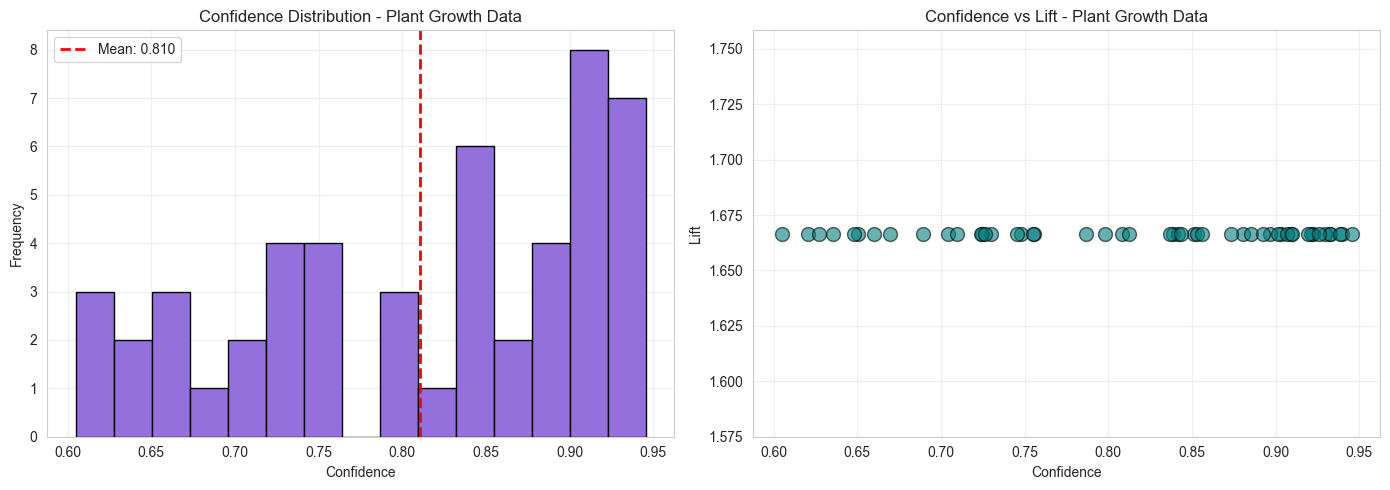


📈 Top 5 Quantitative Rules:
1. Humidity=Humidity_H => Growth_Milestone=Growth_Milestone_H
   Confidence: 0.9454, Lift: 1.6667
2. Water_Frequency=Water_Frequency_H => Water_Frequency=Water_Frequency_M
   Confidence: 0.9396, Lift: 1.6667
3. Fertilizer_Type=Fertilizer_Type_L => Fertilizer_Type=Fertilizer_Type_M
   Confidence: 0.9387, Lift: 1.6667
4. Sunlight_Hours=Sunlight_Hours_M => Sunlight_Hours=Sunlight_Hours_H
   Confidence: 0.9325, Lift: 1.6667
5. Soil_Type=Soil_Type_L => Soil_Type=Soil_Type_H
   Confidence: 0.9324, Lift: 1.6667

✓ Dataset2 berhasil dianalisis


In [39]:
dataset2_path = r'Dataset\Dataset2_CSV_PlantGrowthDataClassification\plant_growth_data.csv'

if os.path.exists(dataset2_path):
    model_plant, data_plant = run_ais_analysis(dataset2_path, "Plant Growth Data", "Growth_Milestone")
    print(f"\n✓ Dataset2 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset2_path}")

## Cell 4: Dataset3 - Agriculture & Farming (Yield Prediction)


AIS ALGORITHM (Agrawal-Imielinski-Swami): Agriculture & Farming (Yield Padi)

📊 Data Shape: (50, 10)
Kolom: ['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 0 data outlier
✓ Label Encoding: 5 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: 8 fitur terpilih

✓ Data setelah preprocessing: (50, 9)

🔍 AIS ALGORITHM MODEL:
✓ Num Intervals: 3
✓ Total Rules: 55
✓ Avg Confidence: 0.7781


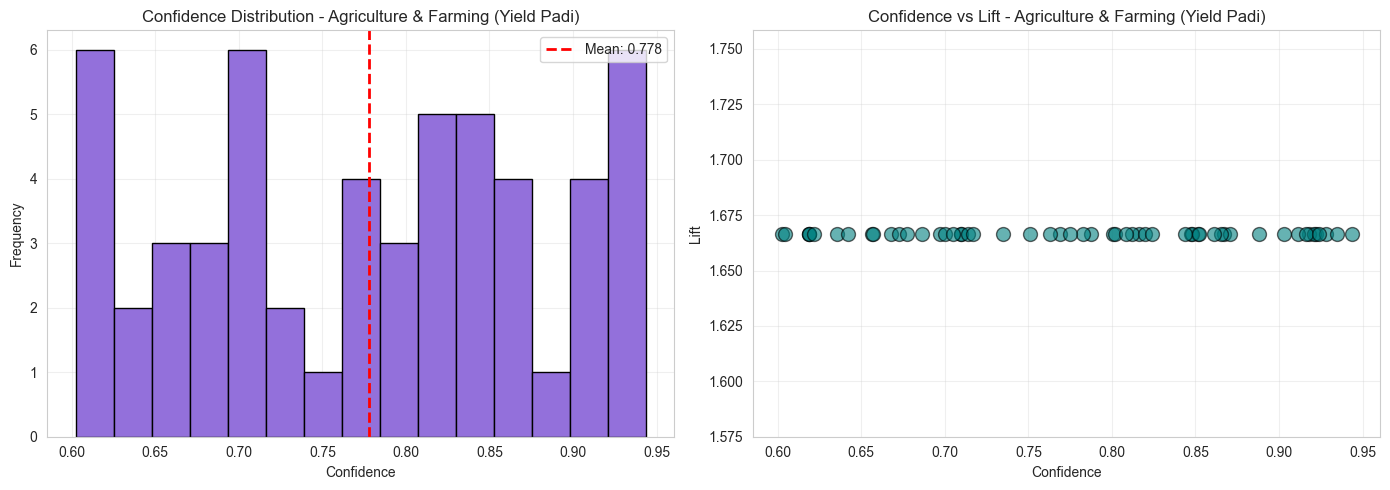


📈 Top 5 Quantitative Rules:
1. Fertilizer_Used(tons)=Fertilizer_Used(tons)_L => Fertilizer_Used(tons)=Fertilizer_Used(tons)_M
   Confidence: 0.9434, Lift: 1.6667
2. Water_Usage(cubic meters)=Water_Usage(cubic meters)_H => Season=Season_H
   Confidence: 0.9348, Lift: 1.6667
3. Pesticide_Used(kg)=Pesticide_Used(kg)_H => Soil_Type=Soil_Type_L
   Confidence: 0.9281, Lift: 1.6667
4. Yield(tons)=Yield(tons)_H => Yield(tons)=Yield(tons)_M
   Confidence: 0.9239, Lift: 1.6667
5. Crop_Type=Crop_Type_H => Crop_Type=Crop_Type_L
   Confidence: 0.9221, Lift: 1.6667

✓ Dataset3 berhasil dianalisis


In [40]:
dataset3_path = r'Dataset\Dataset3_CSV_Agriculture&Farming\agriculture_dataset.csv'

if os.path.exists(dataset3_path):
    model_agri, data_agri = run_ais_analysis(dataset3_path, "Agriculture & Farming (Yield Padi)", "Yield(tons)")
    print(f"\n✓ Dataset3 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset3_path}")

## Cell 5: Model Comparison Summary

In [41]:
print("\n" + "="*60)
print("AIS ALGORITHM MODEL SUMMARY")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A',
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A'],
    'Total Rules': [model_plant.get_summary()['total_rules'] if 'model_plant' in locals() else 0,
                    model_agri.get_summary()['total_rules'] if 'model_agri' in locals() else 0],
    'Avg Confidence': [f"{model_plant.get_summary()['avg_confidence']:.4f}" if 'model_plant' in locals() else 'N/A',
                       f"{model_agri.get_summary()['avg_confidence']:.4f}" if 'model_agri' in locals() else 'N/A']
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


AIS ALGORITHM MODEL SUMMARY

               Dataset Data Shape  Total Rules Avg Confidence
         Plant Growth   (193, 7)           50         0.8104
Agriculture & Farming    (50, 9)           55         0.7781


## Cell 6: Dataset4 - Agricultural Heritage (Seshat Dataset)

In [42]:
# Dataset 4: Agricultural Heritage - Seshat AgriSeshat Dataset
dataset4_path = r'Dataset\Dataset4_CSV_AgriSeshatAgricultureDataset\Agriculture.csv'

if os.path.exists(dataset4_path):
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"AIS ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n📊 Data Shape: {df_seshat.shape}")
    
    # Preprocessing
    categorical_cols = ['NGA', 'Variable', 'Value From', 'Value To', 'Unit']
    existing_cols = [col for col in categorical_cols if col in df_seshat.columns]
    df_seshat_processed = df_seshat[existing_cols].copy()
    
    for col in df_seshat_processed.columns:
        df_seshat_processed[col].fillna(df_seshat_processed[col].mode()[0] if len(df_seshat_processed[col].mode()) > 0 else 'Unknown', inplace=True)
    
    print(f"✓ Handle Missing Values: Selesai")
    
    le_dict = {}
    for col in df_seshat_processed.columns:
        le = LabelEncoder()
        df_seshat_processed[col] = le.fit_transform(df_seshat_processed[col].astype(str))
        le_dict[col] = le
    
    print(f"✓ Label Encoding: {len(df_seshat_processed.columns)} fitur di-encode")
    
    print("\n🔍 AIS MODEL (Dataset4):")
    model_seshat = AISAlgorithm(num_intervals=3, min_support=0.1)
    model_seshat.fit(df_seshat_processed)
    
    summary_seshat = model_seshat.get_summary()
    print(f"✓ Total Rules: {summary_seshat['total_rules']}")
    print(f"✓ Avg Confidence: {summary_seshat['avg_confidence']:.4f}")
    
    print(f"\n✓ Dataset4 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset4_path}")


AIS ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
✓ Handle Missing Values: Selesai
✓ Label Encoding: 5 fitur di-encode

🔍 AIS MODEL (Dataset4):
✓ Total Rules: 29
✓ Avg Confidence: 0.8145

✓ Dataset4 berhasil dianalisis


## Cell 7: Updated Summary - All Datasets

In [43]:
# Final summary with all datasets
print("\n" + "="*60)
print("AIS MODEL SUMMARY - ALL DATASETS")
print("="*60)

summary_data = {
    'Dataset': ['Rice Leaf Diseases', 'Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_rice.shape) if 'data_rice' in locals() else 'N/A',
                   str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Total Rules': [model_rice.get_summary()['total_rules'] if 'model_rice' in locals() else 0,
                    model_plant.get_summary()['total_rules'] if 'model_plant' in locals() else 0,
                    model_agri.get_summary()['total_rules'] if 'model_agri' in locals() else 0,
                    model_seshat.get_summary()['total_rules'] if 'model_seshat' in locals() else 0],
    'Avg Confidence': [f"{model_rice.get_summary()['avg_confidence']:.4f}" if 'model_rice' in locals() else 'N/A',
                       f"{model_plant.get_summary()['avg_confidence']:.4f}" if 'model_plant' in locals() else 'N/A',
                       f"{model_agri.get_summary()['avg_confidence']:.4f}" if 'model_agri' in locals() else 'N/A',
                       f"{model_seshat.get_summary()['avg_confidence']:.4f}" if 'model_seshat' in locals() else 'N/A']
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


AIS MODEL SUMMARY - ALL DATASETS

               Dataset Data Shape  Total Rules Avg Confidence
   Rice Leaf Diseases    (90, 6)           31         0.7523
         Plant Growth   (193, 7)           50         0.8104
Agriculture & Farming    (50, 9)           55         0.7781
Agricultural Heritage   (330, 5)           29         0.8145
